# Sodium/Calcium relationship plot

Copying code from Jacob here

In [61]:
# %% Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# set filepaths
path_to_context = '../../data/broader_context/chem/'
path_to_data = '../../data/sampling/master/'

# ensure plot folder exists
path_to_figures = '../../../figures/discussion/'
os.makedirs(path_to_figures, exist_ok=True)

In [ ]:
# load ALHIC1901 data
alhic1901 = pd.read_csv(path_to_data+'ic_icpms_master.csv')


# keep only the Na and Ca columns
alhic1901_ICPMS = alhic1901[['Ca','Na']]
alhic1901_IC = alhic1901[['Ca+','Na+']]

# drop nans
alhic1901_ICPMS = alhic1901_ICPMS.dropna()
alhic1901_IC = alhic1901_IC.dropna()

In [56]:
# Load EPICA data

# ions.txt appears to be whitespace or tab delimited; using a flexible separator.
epica = pd.read_csv(
    path_to_context+"ions.txt",
    sep=r"\s+",
    engine="python"
)

# Build masks for EPICA glacial and interglacial intervals
glacialI = (
    ((epica["Age_kabp"] >= 20) & (epica["Age_kabp"] <= 80)) |
    ((epica["Age_kabp"] >= 140) & (epica["Age_kabp"] <= 190))
)
interI = (
    ((epica["Age_kabp"] > 1) & (epica["Age_kabp"] <= 15)) |
    ((epica["Age_kabp"] > 115) & (epica["Age_kabp"] <= 130))
)

epicaInter = epica.loc[interI].copy()
epicaGlacial = epica.loc[glacialI].copy()

# keep only Na and Ca columns
epicaInter = epicaInter[['Ca','Na']]
epicaGlacial = epicaGlacial[['Ca','Na']]

# drop nans
epicaInter = epicaInter.dropna()
epicaGlacial = epicaGlacial.dropna()

In [57]:
# load ALHIC1903 data
alhic1903 = pd.read_csv(path_to_context+"ALHIC1903_MajorIons.csv")

# drop nans
ca_col_1903 = 'Ca2+ (µg/L)'
na_col_1903 = 'Na+ (µg/L)'
alhic1903 = alhic1903.dropna(subset=[ca_col_1903,na_col_1903,'Age (ka)']) 

# Split glacial vs interglacial for AH1903
ah1903Glacial = alhic1903[alhic1903["Age (ka)"] >= 134.5].copy()
ah1903Inter = alhic1903[alhic1903["Age (ka)"] <= 134.5].copy()



In [62]:
colors = ["white", "darkblue"] 
custom_blues_cmap = LinearSegmentedColormap.from_list("white_to_darkblue", colors)
cmap_glac = custom_blues_cmap

colors = ["white", "darkred"] 
custom_reds_cmap = LinearSegmentedColormap.from_list("white_to_darkred", colors)
cmap_inter = custom_reds_cmap 


Text(0, 0.5, '')

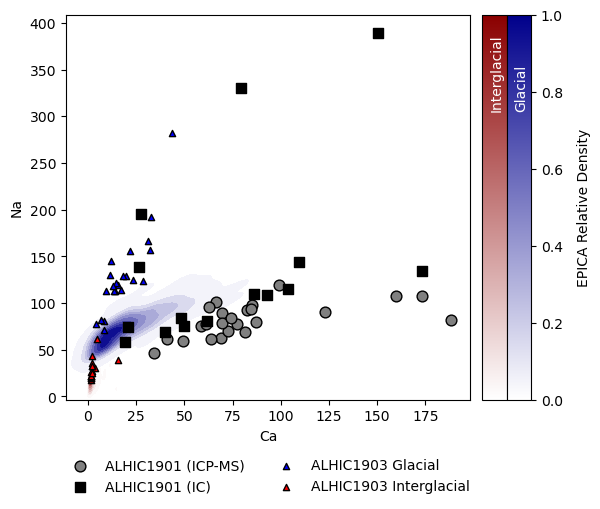

In [91]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(6,5))


# use seaborn kdeplot to plot density contours for EPICA interglacial and glacial
sns.kdeplot(
    data=epicaInter,
    x='Ca',
    y='Na',
    fill=True,
    levels=10,
    cmap=cmap_inter,
    alpha=1,
    thresh=0.01,
    ax=ax,
)
sns.kdeplot(
    data=epicaGlacial,
    x='Ca',
    y='Na',
    fill=True,
    levels=10,
    cmap=cmap_glac,
    alpha=1,
    thresh=0.01,
    ax=ax,
)

# Plot ALHIC1901 points (ICP-MS and IC) and ALHIC1903 if available — filter positive values for log axes
if 'Ca' in alhic1901_ICPMS.columns and 'Na' in alhic1901_ICPMS.columns:
    df_plot = alhic1901_ICPMS[(alhic1901_ICPMS['Ca'] > 0) & (alhic1901_ICPMS['Na'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca'], df_plot['Na'], marker='o', s=60, c='grey', edgecolor='black', label='ALHIC1901 (ICP-MS)', zorder=10)

if 'Ca+' in alhic1901_IC.columns and 'Na+' in alhic1901_IC.columns:
    df_plot = alhic1901_IC[(alhic1901_IC['Ca+'] > 0) & (alhic1901_IC['Na+'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca+'], df_plot['Na+'], marker='s', s=60, c='black', edgecolor='black', label='ALHIC1901 (IC)', zorder=11)

if ca_col_1903 in ah1903Glacial.columns and na_col_1903 in ah1903Glacial.columns:
    df_plot = ah1903Glacial[(np.isfinite(ah1903Glacial[ca_col_1903])) & (np.isfinite(ah1903Glacial[na_col_1903])) & (ah1903Glacial[ca_col_1903] > 0) & (ah1903Glacial[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=20, c='blue', edgecolor='black', label='ALHIC1903 Glacial', zorder=12)
if ca_col_1903 in ah1903Inter.columns and na_col_1903 in ah1903Inter.columns:
    df_plot = ah1903Inter[(np.isfinite(ah1903Inter[ca_col_1903])) & (np.isfinite(ah1903Inter[na_col_1903])) & (ah1903Inter[ca_col_1903] > 0) & (ah1903Inter[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=20, c='red', edgecolor='black', label='ALHIC1903 Interglacial', zorder=12)

# add a legend below the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

# add colorbars for the contours
divider = make_axes_locatable(ax)

# append two narrow axes: give a small pad between plot and first cbar, then zero pad so the two cbars touch
cax1 = divider.append_axes("right", size="6%", pad=0.12)
cax2 = divider.append_axes("right", size="6%", pad=0.0)

# use ScalarMappable objects for the colorbars (empty arrays just to show colormap)
sm_inter = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap_inter)
sm_inter.set_array([])
sm_glac = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap_glac)
sm_glac.set_array([])

cbar_glac = fig.colorbar(sm_inter, cax=cax1, orientation='vertical')
cbar_inter = fig.colorbar(sm_glac, cax=cax2, orientation='vertical')
cbar_inter.set_label('EPICA Relative Density', rotation=90, labelpad=10)

# add text on top of each colorbar in white font, rotated to match the colorbar orientation
cax1.text(0.6, 0.75, 'Interglacial', color='white', fontsize=10, ha='center', va='bottom', rotation=90, transform=cax1.transAxes)
cax2.text(0.6, 0.75, 'Glacial', color='white', fontsize=10, ha='center', va='bottom', rotation=90, transform=cax2.transAxes)


# remove ticks and label for the glacial colorbar
cbar_glac.set_ticks([])
cbar_glac.ax.set_ylabel('')



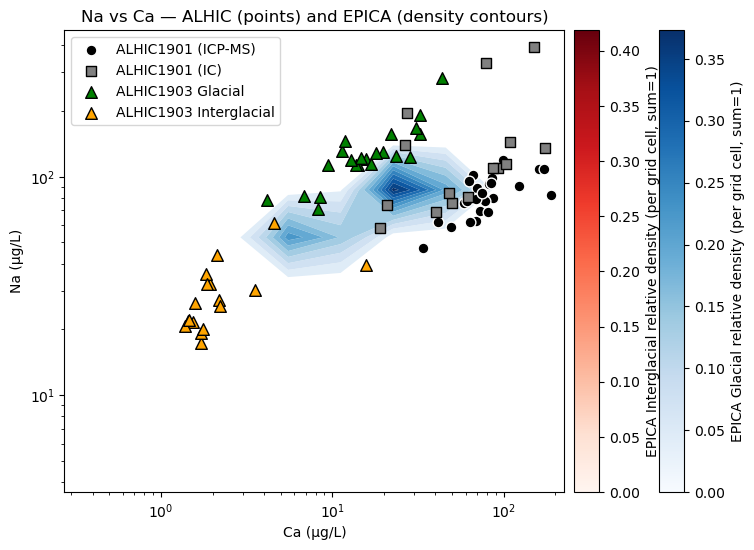

In [60]:
# Cleaned & reordered: log-scale Na vs Ca plot with EPICA KDE contours and ALHIC points

fig, ax = plt.subplots(figsize=(8, 6))

# Helper: KDE computed in log10 space and evaluated on a linear grid (X, Y are in original units)
def kde_on_grid(df, xcol, ycol, X, Y):
    x = df[xcol].values
    y = df[ycol].values
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if not np.any(mask):
        return np.zeros_like(X)
    vals = np.vstack([np.log10(x[mask]), np.log10(y[mask])])
    kde = gaussian_kde(vals)
    positions = np.vstack([np.log10(X.ravel()), np.log10(Y.ravel())])
    Z = kde(positions).reshape(X.shape)
    return Z

# Collect positive data extents from all relevant datasets
datasets = [
    (epicaInter, 'Ca', 'Na'),
    (epicaGlacial, 'Ca', 'Na'),
    (alhic1901_ICPMS, 'Ca', 'Na'),
    (alhic1901_IC, 'Ca+', 'Na+'),
    (ah1903Glacial, ca_col_1903, na_col_1903),
    (ah1903Inter, ca_col_1903, na_col_1903)
]
xs, ys = [], []
for df, xc, yc in datasets:
    if xc in df.columns and yc in df.columns and not df.empty:
        xv = df[xc].values
        yv = df[yc].values
        mask = np.isfinite(xv) & (xv > 0)
        mask2 = np.isfinite(yv) & (yv > 0)
        if np.any(mask):
            xs.append(xv[mask])
        if np.any(mask2):
            ys.append(yv[mask2])

# Fallback sensible defaults if no positive values found
if xs and ys:
    x_min_pos = float(np.min(np.concatenate(xs)))
    x_max_pos = float(np.max(np.concatenate(xs)))
    y_min_pos = float(np.min(np.concatenate(ys)))
    y_max_pos = float(np.max(np.concatenate(ys)))
else:
    x_min_pos, x_max_pos = 1e-2, 200.0
    y_min_pos, y_max_pos = 1e-2, 400.0

# Log-spaced evaluation grid (in original units)
xgrid = np.logspace(np.log10(x_min_pos), np.log10(x_max_pos), 10)
ygrid = np.logspace(np.log10(y_min_pos), np.log10(y_max_pos), 10)
X, Y = np.meshgrid(xgrid, ygrid)

# Compute KDEs for EPICA interglacial and glacial (returns zeros if no data)
Z_inter = kde_on_grid(epicaInter, 'Ca', 'Na', X, Y) if not epicaInter.empty else np.zeros_like(X)
Z_glac  = kde_on_grid(epicaGlacial, 'Ca', 'Na', X, Y) if not epicaGlacial.empty else np.zeros_like(X)

# Normalize to relative densities that sum to 1 across the grid (avoid division by zero)
def to_relative(Z):
    s = Z.sum()
    return Z / s if s > 0 else np.zeros_like(Z)

Z_inter_rel = to_relative(Z_inter)
Z_glac_rel  = to_relative(Z_glac)

# Colormaps and plotting the relative-density contourf layers
cmap_inter = plt.get_cmap('Reds').copy()
cmap_glac  = plt.get_cmap('Blues').copy()
cmap_inter.set_under('white')
cmap_glac.set_under('white')

# Only draw contours when there's nonzero relative density
if np.any(Z_inter_rel > 0):
    im_inter = ax.contourf(X, Y, Z_inter_rel, levels=12, cmap=cmap_inter, alpha=1, antialiased=True, extend='min', vmin=0, vmax=Z_inter_rel.max())
else:
    im_inter = None

if np.any(Z_glac_rel > 0):
    im_glac = ax.contourf(X, Y, Z_glac_rel, levels=12, cmap=cmap_glac, alpha=1, antialiased=True, extend='min', vmin=0, vmax=Z_glac_rel.max())
else:
    im_glac = None

# Plot ALHIC1901 points (ICP-MS and IC) and ALHIC1903 if available — filter positive values for log axes
if 'Ca' in alhic1901_ICPMS.columns and 'Na' in alhic1901_ICPMS.columns:
    df_plot = alhic1901_ICPMS[(alhic1901_ICPMS['Ca'] > 0) & (alhic1901_ICPMS['Na'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca'], df_plot['Na'], marker='o', s=60, c='k', edgecolor='white', label='ALHIC1901 (ICP-MS)', zorder=10)

if 'Ca+' in alhic1901_IC.columns and 'Na+' in alhic1901_IC.columns:
    df_plot = alhic1901_IC[(alhic1901_IC['Ca+'] > 0) & (alhic1901_IC['Na+'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca+'], df_plot['Na+'], marker='s', s=60, c='gray', edgecolor='black', label='ALHIC1901 (IC)', zorder=11)

if ca_col_1903 in ah1903Glacial.columns and na_col_1903 in ah1903Glacial.columns:
    df_plot = ah1903Glacial[(np.isfinite(ah1903Glacial[ca_col_1903])) & (np.isfinite(ah1903Glacial[na_col_1903])) & (ah1903Glacial[ca_col_1903] > 0) & (ah1903Glacial[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=70, c='green', edgecolor='black', label='ALHIC1903 Glacial', zorder=12)
if ca_col_1903 in ah1903Inter.columns and na_col_1903 in ah1903Inter.columns:
    df_plot = ah1903Inter[(np.isfinite(ah1903Inter[ca_col_1903])) & (np.isfinite(ah1903Inter[na_col_1903])) & (ah1903Inter[ca_col_1903] > 0) & (ah1903Inter[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=70, c='orange', edgecolor='black', label='ALHIC1903 Interglacial', zorder=12)

# Axes, labels, log scale, limits, legend
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Ca (µg/L)')
ax.set_ylabel('Na (µg/L)')
ax.set_title('Na vs Ca — ALHIC (points) and EPICA (density contours)')
ax.set_xlim(x_min_pos / 1.2, x_max_pos * 1.2)
ax.set_ylim(y_min_pos / 1.2, y_max_pos * 1.2)
ax.legend(frameon=True)

# Colorbars (one for each EPICA contour if present)
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
if im_inter is not None:
    cax1 = divider.append_axes("right", size="5%", pad=0.1)
    norm1 = plt.Normalize(vmin=0, vmax=Z_inter_rel.max() if Z_inter_rel.max() > 0 else 1)
    cb1 = plt.colorbar(plt.cm.ScalarMappable(norm=norm1, cmap=cmap_inter), cax=cax1)
    cb1.set_label('EPICA Interglacial relative density (per grid cell, sum=1)')
if im_glac is not None:
    # place second colorbar further right
    pad = 0.6 if im_inter is not None else 0.1
    cax2 = divider.append_axes("right", size="5%", pad=pad)
    norm2 = plt.Normalize(vmin=0, vmax=Z_glac_rel.max() if Z_glac_rel.max() > 0 else 1)
    cb2 = plt.colorbar(plt.cm.ScalarMappable(norm=norm2, cmap=cmap_glac), cax=cax2)
    cb2.set_label('EPICA Glacial relative density (per grid cell, sum=1)')

# Save figure
outpath = os.path.join(path_to_figures, 'na_vs_ca_epica_alhic_log.png')
fig.savefig(outpath, dpi=300, bbox_inches='tight')


In [19]:
im_glac

In [9]:
alhic1903.columns

Index(['Pooled Sample Number', 'Top Depth (m)', 'Bot Depth (m)', 'Age (ka)',
       'Cl- (µg/L)', 'NO3- (µg/L)', 'SO42- (µg/L)', 'Na+ (µg/L)', 'K+ (µg/L)',
       'Mg2+ (µg/L)', 'Ca2+ (µg/L)'],
      dtype='object')

In [27]:
Z_glac

array([[1.10170404e-316, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [1.52512981e-271, 5.67620993e-284, 3.28443541e-297, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [1.80205883e-230, 2.33390173e-241, 4.69944753e-253, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        4.55889317e-015, 4.77115131e-019, 7.76314330e-024],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        9.52993941e-014, 3.47069043e-016, 1.96513438e-019],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        1.70036107e-016, 2.15490860e-017, 4.24587489e-019]])

In [21]:
epicaGlacial

,Ca,Na
892,45.40700,99.8736
893,51.04900,102.7010
894,60.28000,102.2750
896,39.68000,83.7000
898,47.78900,118.3090
...,...,...
3661,3.89333,42.0400
3662,7.19750,62.3200
3663,6.30800,54.7020
3664,4.07800,48.8580
